In [1]:
import os

print(os.getcwd())
print(os.listdir("data"))

for f in os.listdir("data"):
    print(f, round(os.path.getsize("data/" + f) / (1024*1024), 2), "MB")

/home/jovyan
['job_skills.csv', 'linkedin_job_postings.csv', 'Untitled.ipynb', '.ipynb_checkpoints', 'job_summary.csv']
job_skills.csv 641.55 MB
linkedin_job_postings.csv 396.09 MB
Untitled.ipynb 0.01 MB
.ipynb_checkpoints 0.0 MB
job_summary.csv 4865.66 MB


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import os

username = os.environ.get("JUPYTERHUB_USER", "unknown_user")

spark = SparkSession.builder \
    .remote("sc://spark-connect.spark.svc.cluster.local:15002") \
    .appName(f"motorsport-job-analytics-{username}") \
    .config("spark.hadoop.fs.defaultFS", "hdfs://namenode.hadoop.svc.cluster.local:8020") \
    .getOrCreate()

print("Spark OK:", spark.version)
print("Test:", spark.range(10).count())

Spark OK: 3.5.8
Test: 10


In [3]:
!hdfs dfs -mkdir -p /user/$JUPYTERHUB_USER/motorsport_job_project/raw

!hdfs dfs -put -f /home/jovyan/data/linkedin_job_postings.csv /user/$JUPYTERHUB_USER/motorsport_job_project/raw/
!hdfs dfs -put -f /home/jovyan/data/job_skills.csv /user/$JUPYTERHUB_USER/motorsport_job_project/raw/
!hdfs dfs -put -f /home/jovyan/data/job_summary.csv /user/$JUPYTERHUB_USER/motorsport_job_project/raw/

!hdfs dfs -ls -lh /user/$JUPYTERHUB_USER/motorsport_job_project/raw

/bin/bash: line 1: hdfs: command not found
/bin/bash: line 1: hdfs: command not found
/bin/bash: line 1: hdfs: command not found
/bin/bash: line 1: hdfs: command not found
/bin/bash: line 1: hdfs: command not found


In [4]:
from pyspark.sql import functions as F

postings = spark.read.option("header", True).option("escape", '"').csv("file:///home/jovyan/data/linkedin_job_postings.csv")
skills = spark.read.option("header", True).option("escape", '"').csv("file:///home/jovyan/data/job_skills.csv")
summaries = spark.read.option("header", True).option("escape", '"').csv("file:///home/jovyan/data/job_summary.csv")

print("Postings:", postings.count())
print("Skills:", skills.count())
print("Summaries:", summaries.count())

print("POSTINGS:", postings.columns)
print("SKILLS:", skills.columns)
print("SUMMARIES:", summaries.columns)

AnalysisException: [PATH_NOT_FOUND] Path does not exist: file:/home/jovyan/data/linkedin_job_postings.csv.

In [5]:
import os

print("cwd:", os.getcwd())
print("data klasörü var mı:", os.path.exists("data"))
print("data içeriği:", os.listdir("data"))

cwd: /home/jovyan
data klasörü var mı: True
data içeriği: ['job_skills.csv', 'linkedin_job_postings.csv', 'Untitled.ipynb', '.ipynb_checkpoints', 'job_summary.csv']


In [6]:
import pandas as pd

print(pd.read_csv("data/linkedin_job_postings.csv", nrows=1).columns.tolist())
print(pd.read_csv("data/job_skills.csv", nrows=1).columns.tolist())
print(pd.read_csv("data/job_summary.csv", nrows=1).columns.tolist())

['job_link', 'last_processed_time', 'got_summary', 'got_ner', 'is_being_worked', 'job_title', 'company', 'job_location', 'first_seen', 'search_city', 'search_country', 'search_position', 'job_level', 'job_type']
['job_link', 'job_skills']
['job_link', 'job_summary']


In [7]:
postings = pd.read_csv("data/linkedin_job_postings.csv")

print(postings.shape)

print(postings.columns.tolist())

KeyboardInterrupt: 

In [8]:
import pandas as pd

postings_iter = pd.read_csv(
    "data/linkedin_job_postings.csv",
    chunksize=100000,
    low_memory=False
)

first_chunk = next(postings_iter)

print("İlk parça boyutu:", first_chunk.shape)
print("Kolonlar:")
print(first_chunk.columns.tolist())
first_chunk.head()

İlk parça boyutu: (100000, 14)
Kolonlar:
['job_link', 'last_processed_time', 'got_summary', 'got_ner', 'is_being_worked', 'job_title', 'company', 'job_location', 'first_seen', 'search_city', 'search_country', 'search_position', 'job_level', 'job_type']


,job_link,last_processed_time,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type
0,https://www.linkedin.com/jobs/view/account-exe...,2024-01-21 07:12:29.00256+00,t,t,f,Account Executive - Dispensing (NorCal/Norther...,BD,"San Diego, CA",2024-01-15,Coronado,United States,Color Maker,Mid senior,Onsite
1,https://www.linkedin.com/jobs/view/registered-...,2024-01-21 07:39:58.88137+00,t,t,f,Registered Nurse - RN Care Manager,Trinity Health MI,"Norton Shores, MI",2024-01-14,Grand Haven,United States,Director Nursing Service,Mid senior,Onsite
2,https://www.linkedin.com/jobs/view/restaurant-...,2024-01-21 07:40:00.251126+00,t,t,f,RESTAURANT SUPERVISOR - THE FORKLIFT,Wasatch Adaptive Sports,"Sandy, UT",2024-01-14,Tooele,United States,Stand-In,Mid senior,Onsite
3,https://www.linkedin.com/jobs/view/independent...,2024-01-21 07:40:00.308133+00,t,t,f,Independent Real Estate Agent,Howard Hanna | Rand Realty,"Englewood Cliffs, NJ",2024-01-16,Pinehurst,United States,Real-Estate Clerk,Mid senior,Onsite
4,https://www.linkedin.com/jobs/view/group-unit-...,2024-01-19 09:45:09.215838+00,f,f,f,Group/Unit Supervisor (Systems Support Manager...,"IRS, Office of Chief Counsel","Chamblee, GA",2024-01-17,Gadsden,United States,Supervisor Travel-Information Center,Mid senior,Onsite


In [9]:
skills_iter = pd.read_csv(
    "data/job_skills.csv",
    chunksize=100000,
    low_memory=False
)

skills_chunk = next(skills_iter)

print("İlk parça boyutu:", skills_chunk.shape)
print("Kolonlar:")
print(skills_chunk.columns.tolist())
skills_chunk.head()

İlk parça boyutu: (100000, 2)
Kolonlar:
['job_link', 'job_skills']


,job_link,job_skills
0,https://www.linkedin.com/jobs/view/housekeeper...,"Building Custodial Services, Cleaning, Janitor..."
1,https://www.linkedin.com/jobs/view/assistant-g...,"Customer service, Restaurant management, Food ..."
2,https://www.linkedin.com/jobs/view/school-base...,"Applied Behavior Analysis (ABA), Data analysis..."
3,https://www.linkedin.com/jobs/view/electrical-...,"Electrical Engineering, Project Controls, Sche..."
4,https://www.linkedin.com/jobs/view/electrical-...,"Electrical Assembly, Point to point wiring, St..."


In [10]:
summary_sample = pd.read_csv(
    "data/job_summary.csv",
    nrows=5,
    low_memory=False
)

print(summary_sample.shape)
print(summary_sample.columns.tolist())
summary_sample.head()

(5, 2)
['job_link', 'job_summary']


,job_link,job_summary
0,https://www.linkedin.com/jobs/view/restaurant-...,Rock N Roll Sushi is hiring a Restaurant Manag...
1,https://www.linkedin.com/jobs/view/med-surg-re...,Schedule\n: PRN is required minimum 12 hours p...
2,https://www.linkedin.com/jobs/view/registered-...,Description\nIntroduction\nAre you looking for...
3,https://uk.linkedin.com/jobs/view/commercial-a...,Commercial account executive\nSheffield\nFull ...
4,https://www.linkedin.com/jobs/view/store-manag...,Address:\nUSA-CT-Newington-44 Fenn Road\nStore...


In [11]:
import pandas as pd

postings_rows = sum(1 for _ in open("data/linkedin_job_postings.csv", encoding="utf-8")) - 1
skills_rows = sum(1 for _ in open("data/job_skills.csv", encoding="utf-8")) - 1
summary_rows = sum(1 for _ in open("data/job_summary.csv", encoding="utf-8")) - 1

print("Postings:", postings_rows)
print("Skills:", skills_rows)
print("Summary:", summary_rows)

Postings: 1348510
Skills: 1296381
Summary: 48219736


In [12]:
import pandas as pd

sample = pd.read_csv(
    "data/linkedin_job_postings.csv",
    usecols=["job_title"],
    nrows=50000
)

keywords = [
    "motorsport",
    "race",
    "racing",
    "formula",
    "vehicle dynamics",
    "simulation",
    "performance engineer",
    "race engineer",
    "nascar",
    "wec",
    "imsa",
    "gt3"
]

for kw in keywords:
    count = sample["job_title"].str.contains(
        kw,
        case=False,
        na=False
    ).sum()

    print(kw, ":", count)

motorsport : 2
race : 7
racing : 0
formula : 5
vehicle dynamics : 0
simulation : 12
performance engineer : 6
race engineer : 0
nascar : 0
wec : 0
imsa : 0
gt3 : 0


In [13]:
import pandas as pd

sample = pd.read_csv(
    "data/job_skills.csv",
    usecols=["job_skills"],
    nrows=100000
)

keywords = [
    "python",
    "sql",
    "machine learning",
    "data analysis",
    "matlab",
    "simulation",
    "cfd",
    "telemetry",
    "vehicle dynamics"
]

for kw in keywords:
    count = sample["job_skills"].str.contains(
        kw,
        case=False,
        na=False
    ).sum()

    print(kw, ":", count)

python : 2247
sql : 2881
machine learning : 665
data analysis : 6013
matlab : 324
simulation : 547
cfd : 90
telemetry : 310
vehicle dynamics : 8


In [14]:
import pandas as pd
import re

core_motorsport_terms = [
    "motorsport", "racing", "formula 1", "f1", "nascar", "indycar",
    "wec", "imsa", "gt3", "motogp", "rally", "trackside",
    "race engineer", "performance engineer", "telemetry engineer"
]

performance_auto_terms = [
    "porsche", "ferrari", "mclaren", "lamborghini", "amg", "bmw m",
    "audi sport", "red bull powertrains", "bosch motorsport",
    "pirelli motorsport", "cosworth", "multimatic", "rimac",
    "koenigsegg", "bugatti", "aston martin", "maserati", "alpine",
    "lotus", "supercar", "hypercar", "sports car",
    "high performance vehicle", "performance automotive"
]

technical_terms = [
    "vehicle dynamics", "simulation", "cfd", "aerodynamics",
    "powertrain", "matlab", "simulink", "telemetry",
    "data acquisition", "calibration", "dyno", "suspension",
    "embedded", "controls engineer", "control systems",
    "python", "sql", "machine learning", "data analysis"
]

def make_pattern(terms):
    return "|".join([re.escape(t) for t in terms])

patterns = {
    "core_motorsport": make_pattern(core_motorsport_terms),
    "performance_auto": make_pattern(performance_auto_terms),
    "technical": make_pattern(technical_terms)
}

usecols = [
    "job_link", "job_title", "company", "job_location",
    "search_city", "search_country", "search_position",
    "job_level", "job_type"
]

counts = {
    "core_motorsport": 0,
    "performance_auto": 0,
    "technical": 0,
    "relevant_total": 0
}

candidate_chunks = []

for chunk in pd.read_csv(
    "data/linkedin_job_postings.csv",
    usecols=usecols,
    chunksize=100000,
    low_memory=False
):
    text = (
        chunk["job_title"].fillna("") + " " +
        chunk["company"].fillna("") + " " +
        chunk["search_position"].fillna("") + " " +
        chunk["job_location"].fillna("")
    ).str.lower()
    
    core_flag = text.str.contains(patterns["core_motorsport"], regex=True, na=False)
    perf_flag = text.str.contains(patterns["performance_auto"], regex=True, na=False)
    tech_flag = text.str.contains(patterns["technical"], regex=True, na=False)
    
    relevant_flag = core_flag | perf_flag | ((core_flag | perf_flag) & tech_flag)
    
    counts["core_motorsport"] += core_flag.sum()
    counts["performance_auto"] += perf_flag.sum()
    counts["technical"] += tech_flag.sum()
    counts["relevant_total"] += relevant_flag.sum()
    
    temp = chunk.loc[relevant_flag].copy()
    temp["core_motorsport_flag"] = core_flag[relevant_flag].values
    temp["performance_auto_flag"] = perf_flag[relevant_flag].values
    temp["technical_flag"] = tech_flag[relevant_flag].values
    
    candidate_chunks.append(temp)

candidates = pd.concat(candidate_chunks, ignore_index=True)

print("Kategori sayımları:")
print(counts)

print("Aday ilan sayısı:", candidates.shape)

candidates.head(20)

Kategori sayımları:
{'core_motorsport': 900, 'performance_auto': 1134, 'technical': 9747, 'relevant_total': 1973}
Aday ilan sayısı: (1973, 12)


,job_link,job_title,company,job_location,search_city,search_country,search_position,job_level,job_type,core_motorsport_flag,performance_auto_flag,technical_flag
0,https://www.linkedin.com/jobs/view/f135-engine...,F135 Engine Instructor (Onsite),Pratt & Whitney,"Patrick AFB, FL",Palm Bay,United States,Instructor,Mid senior,Onsite,True,False,False
1,https://www.linkedin.com/jobs/view/radiologist...,Radiologist,McLaren Health Care,"Detroit, MI",Wyandotte,United States,Radiologist,Mid senior,Onsite,False,True,False
2,https://www.linkedin.com/jobs/view/engineering...,Engineering Manager,WeCare Staffing Solutions Inc,"Saline, MI",Michigan,United States,Chief Engineer,Mid senior,Onsite,True,False,False
3,https://www.linkedin.com/jobs/view/purchasing-...,Purchasing Manager,Weco Manufacturing Group,"Ontario, NY",Williamson,United States,Vendor,Mid senior,Onsite,True,False,False
4,https://www.linkedin.com/jobs/view/emergency-d...,Emergency Dep. Registered Nurse- Augusta,WeCare Staffing Solutions Inc,"Augusta, GA",Aiken,United States,Nurse School,Mid senior,Onsite,True,False,False
5,https://www.linkedin.com/jobs/view/sr-records-...,Sr. Records Manager (TS/SCI) - DODF1 with Secu...,ClearanceJobs,"Arlington, VA",Silver Spring,United States,Supervisor Electronics Processing,Mid senior,Onsite,True,False,False
6,https://www.linkedin.com/jobs/view/assistant-m...,Assistant Manager-Franchise - 3663 - Hwy 6 - N...,Checkers & Rally’s Drive-In Restaurants,"Navasota, TX",College Park,United States,Clerk General,Mid senior,Onsite,True,False,False
7,https://www.linkedin.com/jobs/view/building-pe...,Building Performance Engineer,HDR,"Colorado Springs, CO",Cripple Creek,United States,Starter,Mid senior,Onsite,True,False,False
8,https://www.linkedin.com/jobs/view/nurse-manag...,Nurse Manager of L&amp;D RN - Houston TX*,WeCare Staffing Solutions Inc,"Houston, TX",Baytown,United States,Nurse Consultant,Mid senior,Onsite,True,False,False
9,https://www.linkedin.com/jobs/view/building-pe...,Building Performance Engineer,HDR,"Charlotte, NC",Gastonia,United States,Value Engineer,Mid senior,Onsite,True,False,False


In [15]:
import pandas as pd

country_counts = {}

for chunk in pd.read_csv(
    "data/linkedin_job_postings.csv",
    usecols=["search_country"],
    chunksize=100000,
    low_memory=False
):
    vc = chunk["search_country"].value_counts(dropna=False)

    for k, v in vc.items():
        country_counts[k] = country_counts.get(k, 0) + v

country_counts = (
    pd.Series(country_counts)
    .sort_values(ascending=False)
)

print(country_counts.head(20))

United States     1149342
United Kingdom     113421
Canada              55972
Australia           29719
dtype: int64


In [16]:
import pandas as pd

sample = pd.read_csv(
    "data/linkedin_job_postings.csv",
    usecols=["search_country","search_city"],
    nrows=10000
)

print(sample.head(20))

        search_city  search_country
0          Coronado   United States
1       Grand Haven   United States
2            Tooele   United States
3         Pinehurst   United States
4           Gadsden   United States
5        Oyster Bay   United States
6          Muskegon   United States
7      White Plains   United States
8            Slough  United Kingdom
9          Manitoba          Canada
10           Austin   United States
11       Louisville   United States
12     Hillsborough   United States
13         Nebraska   United States
14           Carmel   United States
15            Derby   United States
16     Calumet City   United States
17           Merced   United States
18  New South Wales       Australia
19          Lebanon   United States


In [17]:
import pandas as pd

performance_companies = [
    "Ferrari",
    "Porsche",
    "McLaren",
    "Mercedes",
    "AMG",
    "BMW",
    "Audi",
    "Lamborghini",
    "Aston Martin",
    "Red Bull",
    "Williams",
    "Bosch",
    "Pirelli",
    "Cosworth",
    "Multimatic",
    "Rimac",
    "Koenigsegg"
]

sample = pd.read_csv(
    "data/linkedin_job_postings.csv",
    usecols=["company"],
    nrows=200000
)

for company in performance_companies:
    count = sample["company"].fillna("").str.contains(
        company,
        case=False,
        na=False
    ).sum()

    print(company, ":", count)

Ferrari : 0
Porsche : 2
McLaren : 49
Mercedes : 4
AMG : 8
BMW : 18
Audi : 40
Lamborghini : 0
Aston Martin : 0
Red Bull : 11
Williams : 202
Bosch : 24
Pirelli : 0
Cosworth : 0
Multimatic : 2
Rimac : 7
Koenigsegg : 0


In [1]:
import pandas as pd

postings_sample = pd.read_csv(
    "data/linkedin_job_postings.csv",
    nrows=50000,
    low_memory=False
)

skills_sample = pd.read_csv(
    "data/job_skills.csv",
    nrows=50000,
    low_memory=False
)

summary_sample = pd.read_csv(
    "data/job_summary.csv",
    nrows=50000,
    low_memory=False
)

print(postings_sample.shape)
print(skills_sample.shape)
print(summary_sample.shape)

(50000, 14)
(50000, 2)
(50000, 2)


In [2]:
jobs = postings_sample.merge(
    skills_sample,
    on="job_link",
    how="left"
)

jobs = jobs.merge(
    summary_sample,
    on="job_link",
    how="left"
)

print(jobs.shape)

jobs[[
    "job_title",
    "company",
    "job_skills",
    "job_summary"
]].head()

(50000, 16)


,job_title,company,job_skills,job_summary
0,Account Executive - Dispensing (NorCal/Norther...,BD,NaN,NaN
1,Registered Nurse - RN Care Manager,Trinity Health MI,NaN,NaN
2,RESTAURANT SUPERVISOR - THE FORKLIFT,Wasatch Adaptive Sports,NaN,NaN
3,Independent Real Estate Agent,Howard Hanna | Rand Realty,NaN,NaN
4,Group/Unit Supervisor (Systems Support Manager...,"IRS, Office of Chief Counsel",NaN,NaN


In [3]:
print("Skill dolu satırlar:",
      jobs["job_skills"].notna().sum())

print("Summary dolu satırlar:",
      jobs["job_summary"].notna().sum())

Skill dolu satırlar: 772
Summary dolu satırlar: 2419


In [1]:
import pandas as pd

target_terms = [
    "python", "sql", "machine learning", "data analysis",
    "matlab", "simulation", "cfd", "telemetry",
    "vehicle dynamics", "simulink", "aerodynamics",
    "powertrain", "data acquisition", "calibration"
]

matched_skill_chunks = []

for chunk in pd.read_csv(
    "data/job_skills.csv",
    chunksize=100000,
    low_memory=False
):
    skill_text = chunk["job_skills"].fillna("").str.lower()
    
    mask = False
    for term in target_terms:
        mask = mask | skill_text.str.contains(term, case=False, na=False, regex=False)
    
    matched_skill_chunks.append(chunk[mask])

matched_skills = pd.concat(matched_skill_chunks, ignore_index=True)

print("Hedef becerilerle eşleşen skill kayıt sayısı:", matched_skills.shape)
print(matched_skills.head())

Hedef becerilerle eşleşen skill kayıt sayısı: (147699, 2)
                                            job_link  \
0  https://www.linkedin.com/jobs/view/school-base...   
1  https://www.linkedin.com/jobs/view/senior-lead...   
2  https://www.linkedin.com/jobs/view/sr-technici...   
3  https://ca.linkedin.com/jobs/view/performance-...   
4  https://www.linkedin.com/jobs/view/laboratory-...   

                                          job_skills  
0  Applied Behavior Analysis (ABA), Data analysis...  
1  Access Control, Video Management Systems, IPba...  
2  Optical Inspection Equipment Programming, MS E...  
3  SAP, DRMIS, Data warehousing, Data analysis, D...  
4  Laboratory Technician, Pharmaceutical Testing,...  


In [2]:
target_links = set(matched_skills["job_link"].dropna().unique())

print("Eşsiz hedef ilan linki sayısı:", len(target_links))

Eşsiz hedef ilan linki sayısı: 147699


In [3]:
matched_posting_chunks = []

for chunk in pd.read_csv(
    "data/linkedin_job_postings.csv",
    chunksize=100000,
    low_memory=False
):
    mask = chunk["job_link"].isin(target_links)
    matched_posting_chunks.append(chunk[mask])

matched_postings = pd.concat(matched_posting_chunks, ignore_index=True)

print("Eşleşen ilan sayısı:", matched_postings.shape)
matched_postings.head()

Eşleşen ilan sayısı: (147699, 14)


,job_link,last_processed_time,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type
0,https://www.linkedin.com/jobs/view/senior-asso...,2024-01-21 02:01:10.496553+00,t,t,f,"Senior Associate, Tax - Product Analyst",KPMG US,"Chicago, IL",2024-01-14,Calumet City,United States,Stand-In,Associate,Onsite
1,https://www.linkedin.com/jobs/view/test-conduc...,2024-01-21 06:01:19.472942+00,t,t,f,Test Conductor - Space Systems,Northrop Grumman,"Gilbert, AZ",2024-01-15,Chandler,United States,Conductor,Mid senior,Onsite
2,https://www.linkedin.com/jobs/view/builder-ter...,2024-01-21 06:01:12.676071+00,t,t,f,"Builder Territory Manager - Seattle , WA",Shaw Industries,"Seattle, WA",2024-01-16,Bellevue,United States,Exhibit Builder,Mid senior,Onsite
3,https://www.linkedin.com/jobs/view/asset-wealt...,2024-01-21 07:12:35.384792+00,t,t,f,Asset Wealth Management – Regulated Investment...,PwC,"Sacramento, CA",2024-01-14,Davis,United States,Manager Records Analysis,Mid senior,Onsite
4,https://www.linkedin.com/jobs/view/finance-man...,2024-01-19 14:39:50.288894+00,t,t,f,Finance Manager,Aston Carter,"Southlake, TX",2024-01-17,Corinth,United States,Supervisor Line Department,Mid senior,Onsite


In [1]:
matched_summary_chunks = []

for chunk in pd.read_csv(
    "data/job_summary.csv",
    chunksize=100000,
    low_memory=False
):
    mask = chunk["job_link"].isin(target_links)
    matched_summary_chunks.append(chunk[mask])

matched_summaries = pd.concat(matched_summary_chunks, ignore_index=True)

print("Eşleşen summary sayısı:", matched_summaries.shape)
matched_summaries.head()

NameError: name 'pd' is not defined

In [2]:
import pandas as pd

target_terms = [
    "python", "sql", "machine learning", "data analysis",
    "matlab", "simulation", "cfd", "telemetry",
    "vehicle dynamics", "simulink", "aerodynamics",
    "powertrain", "data acquisition", "calibration"
]

matched_skill_chunks = []

for chunk in pd.read_csv(
    "data/job_skills.csv",
    chunksize=100000,
    low_memory=False
):
    skill_text = chunk["job_skills"].fillna("").str.lower()
    
    mask = False
    for term in target_terms:
        mask = mask | skill_text.str.contains(term, case=False, na=False, regex=False)
    
    matched_skill_chunks.append(chunk[mask])

matched_skills = pd.concat(matched_skill_chunks, ignore_index=True)
target_links = set(matched_skills["job_link"].dropna().unique())

print("Hedef skill kayıt sayısı:", matched_skills.shape)
print("Eşsiz hedef ilan linki:", len(target_links))

Hedef skill kayıt sayısı: (147699, 2)
Eşsiz hedef ilan linki: 147699


In [3]:
matched_posting_chunks = []

for chunk in pd.read_csv(
    "data/linkedin_job_postings.csv",
    chunksize=100000,
    low_memory=False
):
    mask = chunk["job_link"].isin(target_links)
    matched_posting_chunks.append(chunk[mask])

matched_postings = pd.concat(matched_posting_chunks, ignore_index=True)

print("Eşleşen ilan sayısı:", matched_postings.shape)

Eşleşen ilan sayısı: (147699, 14)


In [1]:
matched_summary_chunks = []

for chunk in pd.read_csv(
    "data/job_summary.csv",
    chunksize=100000,
    low_memory=False
):
    mask = chunk["job_link"].isin(target_links)
    matched_summary_chunks.append(chunk[mask])

matched_summaries = pd.concat(matched_summary_chunks, ignore_index=True)

print("Eşleşen summary sayısı:", matched_summaries.shape)
matched_summaries.head()

NameError: name 'pd' is not defined

In [ ]:
import pandas as pd

matched_summary_chunks = []

for chunk in pd.read_csv(
    "data/job_summary.csv",
    chunksize=100000,
    low_memory=False
):
    mask = chunk["job_link"].isin(target_links)
    matched_summary_chunks.append(chunk[mask])

matched_summaries = pd.concat(matched_summary_chunks, ignore_index=True)

print("Eşleşen summary sayısı:", matched_summaries.shape)
matched_summaries.head()

In [1]:
import pandas as pd

jobs_final = matched_postings.merge(
    matched_skills,
    on="job_link",
    how="left"
)

print("Final veri seti:", jobs_final.shape)
print("Skill dolu:", jobs_final["job_skills"].notna().sum())

jobs_final[[
    "job_title",
    "company",
    "job_location",
    "search_country",
    "job_level",
    "job_type",
    "job_skills"
]].head()

NameError: name 'matched_postings' is not defined

In [2]:
import pandas as pd

target_terms = [
    "python", "sql", "machine learning", "data analysis",
    "matlab", "simulation", "cfd", "telemetry",
    "vehicle dynamics", "simulink", "aerodynamics",
    "powertrain", "data acquisition", "calibration"
]

# 1) Hedef skill kayıtlarını bul
matched_skill_chunks = []

for chunk in pd.read_csv(
    "data/job_skills.csv",
    chunksize=100000,
    low_memory=False
):
    skill_text = chunk["job_skills"].fillna("").str.lower()
    
    mask = False
    for term in target_terms:
        mask = mask | skill_text.str.contains(term, case=False, na=False, regex=False)
    
    matched_skill_chunks.append(chunk[mask])

matched_skills = pd.concat(matched_skill_chunks, ignore_index=True)
target_links = set(matched_skills["job_link"].dropna().unique())

print("Hedef skill kayıt sayısı:", matched_skills.shape)
print("Eşsiz hedef ilan linki:", len(target_links))

# 2) Bu ilanların posting bilgilerini çek
matched_posting_chunks = []

for chunk in pd.read_csv(
    "data/linkedin_job_postings.csv",
    chunksize=100000,
    low_memory=False
):
    mask = chunk["job_link"].isin(target_links)
    matched_posting_chunks.append(chunk[mask])

matched_postings = pd.concat(matched_posting_chunks, ignore_index=True)

print("Eşleşen posting sayısı:", matched_postings.shape)

# 3) Posting + skills birleştir
jobs_final = matched_postings.merge(
    matched_skills,
    on="job_link",
    how="left"
)

print("Final veri seti:", jobs_final.shape)
print("Skill dolu:", jobs_final["job_skills"].notna().sum())

jobs_final.to_csv(
    "data/motorsport_performance_jobs_final.csv",
    index=False
)

print("Kaydedildi: data/motorsport_performance_jobs_final.csv")

jobs_final[[
    "job_title",
    "company",
    "job_location",
    "search_country",
    "job_level",
    "job_type",
    "job_skills"
]].head()

Hedef skill kayıt sayısı: (147699, 2)
Eşsiz hedef ilan linki: 147699
Eşleşen posting sayısı: (147699, 14)
Final veri seti: (147699, 15)
Skill dolu: 147699
Kaydedildi: data/motorsport_performance_jobs_final.csv


,job_title,company,job_location,search_country,job_level,job_type,job_skills
0,"Senior Associate, Tax - Product Analyst",KPMG US,"Chicago, IL",United States,Associate,Onsite,"Microsoft Office Suite, UML, Flow Charting Sof..."
1,Test Conductor - Space Systems,Northrop Grumman,"Gilbert, AZ",United States,Mid senior,Onsite,"Electrical Engineering, Requirements Derivatio..."
2,"Builder Territory Manager - Seattle , WA",Shaw Industries,"Seattle, WA",United States,Mid senior,Onsite,"Flooring sales, Interior design, Sales, Commun..."
3,Asset Wealth Management – Regulated Investment...,PwC,"Sacramento, CA",United States,Mid senior,Onsite,"Tax, CPA, Form 1120RIC, RICs, Shareholder repo..."
4,Finance Manager,Aston Carter,"Southlake, TX",United States,Mid senior,Onsite,"Budgeting, Budgeting Analytics, Cognos, Data A..."


In [1]:
import pandas as pd

jobs = pd.read_csv("data/motorsport_performance_jobs_final.csv", low_memory=False)

# Metin alanını hazırlıyoruz
jobs["skill_text"] = jobs["job_skills"].fillna("").str.lower()
jobs["title_text"] = jobs["job_title"].fillna("").str.lower()
jobs["company_text"] = jobs["company"].fillna("").str.lower()

data_skills = [
    "python", "sql", "machine learning", "data analysis",
    "power bi", "tableau", "statistics", "analytics",
    "data visualization", "etl", "spark"
]

engineering_skills = [
    "matlab", "simulink", "simulation", "cfd",
    "aerodynamics", "powertrain", "calibration",
    "control systems", "embedded", "data acquisition"
]

motorsport_performance_skills = [
    "telemetry", "vehicle dynamics", "cfd", "aerodynamics",
    "simulation", "data acquisition", "calibration",
    "powertrain", "dyno", "trackside"
]

def count_terms(text, terms):
    return sum(term in text for term in terms)

jobs["data_skill_score"] = jobs["skill_text"].apply(lambda x: count_terms(x, data_skills))
jobs["engineering_skill_score"] = jobs["skill_text"].apply(lambda x: count_terms(x, engineering_skills))
jobs["motorsport_skill_score"] = jobs["skill_text"].apply(lambda x: count_terms(x, motorsport_performance_skills))

jobs["career_value_score"] = (
    jobs["data_skill_score"] +
    jobs["engineering_skill_score"] +
    jobs["motorsport_skill_score"]
)

print(jobs[[
    "job_title",
    "company",
    "data_skill_score",
    "engineering_skill_score",
    "motorsport_skill_score",
    "career_value_score"
]].head(20))

print("Ortalama data skill:", jobs["data_skill_score"].mean())
print("Ortalama engineering skill:", jobs["engineering_skill_score"].mean())
print("Ortalama motorsport skill:", jobs["motorsport_skill_score"].mean())
print("Ortalama career value:", jobs["career_value_score"].mean())

                                            job_title  \
0             Senior Associate, Tax - Product Analyst   
1                      Test Conductor - Space Systems   
2            Builder Territory Manager - Seattle , WA   
3   Asset Wealth Management – Regulated Investment...   
4                                     Finance Manager   
5                    Superintendent, Process Engineer   
6                        Electrical Engineer 23-01066   
7                                Optical Engineers IV   
8                    Lead Software Engineer, Back End   
9             Founding Fullstack Engineer, AI Startup   
10                   Stakeholder Relationship Manager   
11                                      Fleet Manager   
12                                RESEARCH ANALYST II   
13     Connected Supply Chain O9 Technology - Manager   
14                                 OIG Investigator I   
15                       Ad Operations Manager (Hulu)   
16                   Senior Sof

In [2]:
def classify_career(score):
    if score >= 4:
        return "High"
    elif score >= 2:
        return "Medium"
    else:
        return "Low"

jobs["career_class"] = jobs["career_value_score"].apply(classify_career)

print(jobs["career_class"].value_counts())

jobs[[
    "job_title",
    "company",
    "job_level",
    "job_type",
    "data_skill_score",
    "engineering_skill_score",
    "motorsport_skill_score",
    "career_value_score",
    "career_class"
]].head(20)

career_class
Low       94926
Medium    40953
High      11820
Name: count, dtype: int64


,job_title,company,job_level,job_type,data_skill_score,engineering_skill_score,motorsport_skill_score,career_value_score,career_class
0,"Senior Associate, Tax - Product Analyst",KPMG US,Associate,Onsite,1,0,0,1,Low
1,Test Conductor - Space Systems,Northrop Grumman,Mid senior,Onsite,1,0,0,1,Low
2,"Builder Territory Manager - Seattle , WA",Shaw Industries,Mid senior,Onsite,1,0,0,1,Low
3,Asset Wealth Management – Regulated Investment...,PwC,Mid senior,Onsite,1,0,0,1,Low
4,Finance Manager,Aston Carter,Mid senior,Onsite,2,0,0,2,Medium
5,"Superintendent, Process Engineer",Nutrien,Mid senior,Onsite,1,0,0,1,Low
6,Electrical Engineer 23-01066,ESPO Corporation,Associate,Onsite,0,3,0,3,Medium
7,Optical Engineers IV,STS Technical Services,Mid senior,Onsite,1,1,0,2,Medium
8,"Lead Software Engineer, Back End",ClickJobs.io,Mid senior,Onsite,2,0,0,2,Medium
9,"Founding Fullstack Engineer, AI Startup",Recruiting from Scratch,Mid senior,Onsite,3,0,0,3,Medium


In [3]:
motorsport_company_terms = [
    "porsche", "ferrari", "mclaren", "mercedes", "amg", "bmw", "audi",
    "red bull", "rimac", "bosch", "multimatic", "aston martin",
    "lamborghini", "pirelli", "cosworth", "williams"
]

motorsport_title_terms = [
    "race", "racing", "motorsport", "formula", "f1", "nascar",
    "performance engineer", "simulation engineer", "vehicle dynamics",
    "aerodynamics", "powertrain", "calibration", "test engineer",
    "controls engineer", "embedded", "mechanical engineer",
    "data engineer", "data analyst", "machine learning engineer"
]

motorsport_skill_terms = [
    "telemetry", "vehicle dynamics", "cfd", "aerodynamics",
    "simulation", "simulink", "matlab", "powertrain",
    "calibration", "data acquisition", "control systems",
    "embedded", "dyno", "suspension"
]

def contains_any(series, terms):
    s = series.fillna("").str.lower()
    mask = False
    for term in terms:
        mask = mask | s.str.contains(term, case=False, na=False, regex=False)
    return mask

company_flag = contains_any(jobs["company"], motorsport_company_terms)
title_flag = contains_any(jobs["job_title"], motorsport_title_terms)
skill_flag = contains_any(jobs["job_skills"], motorsport_skill_terms)

# Daraltılmış proje veri seti:
# Ya motorsporu/performance şirket adı geçecek
# ya başlık teknik/performance odaklı olacak
# ya da skill tarafında motorsporu/performance mühendislik becerisi olacak
jobs_focus = jobs[company_flag | title_flag | skill_flag].copy()

print("Ana teknik havuz:", jobs.shape)
print("Odak motorsporu/performance otomotiv havuzu:", jobs_focus.shape)

jobs_focus[[
    "job_title",
    "company",
    "job_location",
    "search_country",
    "job_level",
    "job_type",
    "job_skills",
    "data_skill_score",
    "engineering_skill_score",
    "motorsport_skill_score",
    "career_value_score",
    "career_class"
]].head(30)

Ana teknik havuz: (147699, 23)
Odak motorsporu/performance otomotiv havuzu: (32681, 23)


,job_title,company,job_location,search_country,job_level,job_type,job_skills,data_skill_score,engineering_skill_score,motorsport_skill_score,career_value_score,career_class
6,Electrical Engineer 23-01066,ESPO Corporation,"Rockford, IL",United States,Associate,Onsite,"Electrical Engineering, Motors, Sensors, Conne...",0,3,0,3,Medium
7,Optical Engineers IV,STS Technical Services,"San Francisco, CA",United States,Mid senior,Onsite,"Optical design, Zemax, FRED, Optical subassemb...",1,1,0,2,Medium
18,Senior Machine Learning Engineer,Jobs for Humanity,"New Haven, CT",United States,Mid senior,Onsite,"Machine Learning, Programming, Python, Scala, ...",4,0,0,4,High
21,Travel RN Peds Onc 3184.24/week - 24183827EXPPLAT,TravelNurseSource,"Madera, CA",United States,Mid senior,Onsite,"Pediatrics RN, BLS, PALS, American Heart Assoc...",0,0,1,1,Low
22,Strategic Content and Relationship Management ...,Jobs via eFinancialCareers,"Southfield, MI",United States,Mid senior,Onsite,"Licensing agreements, Vendor management, Contr...",0,1,1,2,Medium
23,Contracts Lifecycle Management (CLM) Solutions...,PwC,"Detroit, MI",United States,Mid senior,Onsite,"Data Analytics, Business Intelligence, Data Ma...",2,1,0,3,Medium
35,Hospice Registered Nurse,Gentiva,"St Louis, MO",United States,Mid senior,Onsite,"Nursing, Hospice Care, Palliative Care, Medica...",0,0,1,1,Low
62,Cardio EKG - Exercise Physiologist,Children's Health,"Dallas, TX",United States,Mid senior,Onsite,"EKG, Telemetry, Cardiac monitors, Rhythm analy...",0,0,1,1,Low
68,"Sr. Medical Physicist (Texarkana, TX)",Varian,"Nashville, TN",United States,Mid senior,Onsite,"Radiation Therapy, Radiation Safety, Dosimetry...",0,2,2,4,High
74,Stack Emissions Testing- Operations Manager,Alliance Technical Group,"Tempe, AZ",United States,Mid senior,Onsite,"Stack Emissions Testing, Wet Chemistry, Instru...",0,1,1,2,Medium


In [4]:

exclude_terms = [
    "nurse", "rn", "registered nurse", "nursing", "healthcare",
    "hospital", "patient", "cardiac", "medical", "physician",
    "oncology", "clinical", "therapist", "radiation",
    "tax", "finance manager", "wealth management", "real estate",
    "restaurant", "custodial", "janitor", "forklift"
]

include_strong_terms = [
    "simulation", "simulink", "matlab", "cfd", "aerodynamics",
    "vehicle dynamics", "powertrain", "calibration",
    "data acquisition", "control systems", "embedded",
    "mechanical engineer", "electrical engineer",
    "test engineer", "systems engineer", "software engineer",
    "machine learning engineer", "data engineer",
    "performance engineer", "race engineer", "motorsport",
    "racing", "automotive", "aerospace", "robotics",
    "battery", "ev", "autonomous", "lidar", "sensor"
]

combined_text = (
    jobs["job_title"].fillna("") + " " +
    jobs["company"].fillna("") + " " +
    jobs["job_skills"].fillna("")
).str.lower()

exclude_flag = False
for term in exclude_terms:
    exclude_flag = exclude_flag | combined_text.str.contains(term, case=False, na=False, regex=False)

strong_flag = False
for term in include_strong_terms:
    strong_flag = strong_flag | combined_text.str.contains(term, case=False, na=False, regex=False)

jobs_focus_clean = jobs[strong_flag & ~exclude_flag].copy()

print("Önceki odak havuz:", jobs_focus.shape)
print("Temizlenmiş odak havuz:", jobs_focus_clean.shape)

jobs_focus_clean[[
    "job_title",
    "company",
    "job_location",
    "search_country",
    "job_level",
    "job_type",
    "job_skills",
    "data_skill_score",
    "engineering_skill_score",
    "motorsport_skill_score",
    "career_value_score",
    "career_class"
]].head(30)

Önceki odak havuz: (32681, 23)
Temizlenmiş odak havuz: (45260, 23)


,job_title,company,job_location,search_country,job_level,job_type,job_skills,data_skill_score,engineering_skill_score,motorsport_skill_score,career_value_score,career_class
1,Test Conductor - Space Systems,Northrop Grumman,"Gilbert, AZ",United States,Mid senior,Onsite,"Electrical Engineering, Requirements Derivatio...",1,0,0,1,Low
5,"Superintendent, Process Engineer",Nutrien,"Augusta, GA",United States,Mid senior,Onsite,"Safety, Production, Chemical Engineering, Proc...",1,0,0,1,Low
6,Electrical Engineer 23-01066,ESPO Corporation,"Rockford, IL",United States,Associate,Onsite,"Electrical Engineering, Motors, Sensors, Conne...",0,3,0,3,Medium
7,Optical Engineers IV,STS Technical Services,"San Francisco, CA",United States,Mid senior,Onsite,"Optical design, Zemax, FRED, Optical subassemb...",1,1,0,2,Medium
16,"Senior Software Engineer, DevOps",Jobs for Humanity,"Atlantic City, NJ",United States,Mid senior,Onsite,"DevOps, Cloud Native technologies, Amazon Web ...",2,0,0,2,Medium
17,Manufacturing Supervisor- Mirum & Endwell - 3...,NFW,"Peoria, IL",United States,Mid senior,Onsite,"Bachelor's in Chemistry, Chemical Engineering,...",1,0,0,1,Low
19,"Supply Chain Manager, Amazon Freight, Amazon F...",Amazon,"Bellevue, WA",United States,Mid senior,Onsite,"Data Analysis, Program Management, Project Man...",1,0,0,1,Low
20,Quality Assurance Specialist,Archetype Permanent Solutions,"Austin, TX",United States,Mid senior,Onsite,"Quality Assurance, Product Testing, Process Ev...",1,0,0,1,Low
22,Strategic Content and Relationship Management ...,Jobs via eFinancialCareers,"Southfield, MI",United States,Mid senior,Onsite,"Licensing agreements, Vendor management, Contr...",0,1,1,2,Medium
26,"Territory Manager Hard Surface (Frederick, Mar...",Mohawk Industries,"Frederick, MD",United States,Mid senior,Onsite,"Sales skills, Expertise, Knowledge of marketin...",1,0,0,1,Low


In [5]:
role_terms = [
    "engineer", "engineering", "developer", "software",
    "data scientist", "data analyst", "data engineer",
    "machine learning", "ml engineer", "ai engineer",
    "analyst", "systems engineer", "test engineer",
    "simulation", "controls", "embedded", "mechanical",
    "electrical", "aerospace", "automotive", "robotics",
    "power electronics", "firmware", "calibration"
]

bad_role_terms = [
    "nurse", "registered nurse", "rn", "sales", "account executive",
    "finance manager", "wealth management", "tax", "restaurant",
    "supervisor", "territory manager", "customer", "custodial",
    "geology", "safety manager", "volunteer", "real estate"
]

title_text = jobs_focus_clean["job_title"].fillna("").str.lower()
skill_text = jobs_focus_clean["job_skills"].fillna("").str.lower()
combined = title_text + " " + skill_text

role_flag = False
for term in role_terms:
    role_flag = role_flag | combined.str.contains(term, case=False, na=False, regex=False)

bad_flag = False
for term in bad_role_terms:
    bad_flag = bad_flag | combined.str.contains(term, case=False, na=False, regex=False)

jobs_focus_final = jobs_focus_clean[role_flag & ~bad_flag].copy()

print("Temizlenmiş havuz:", jobs_focus_clean.shape)
print("Final odak havuz:", jobs_focus_final.shape)

jobs_focus_final[[
    "job_title",
    "company",
    "job_location",
    "search_country",
    "job_level",
    "job_type",
    "job_skills",
    "data_skill_score",
    "engineering_skill_score",
    "motorsport_skill_score",
    "career_value_score",
    "career_class"
]].head(40)

Temizlenmiş havuz: (45260, 23)
Final odak havuz: (25570, 23)


,job_title,company,job_location,search_country,job_level,job_type,job_skills,data_skill_score,engineering_skill_score,motorsport_skill_score,career_value_score,career_class
1,Test Conductor - Space Systems,Northrop Grumman,"Gilbert, AZ",United States,Mid senior,Onsite,"Electrical Engineering, Requirements Derivatio...",1,0,0,1,Low
5,"Superintendent, Process Engineer",Nutrien,"Augusta, GA",United States,Mid senior,Onsite,"Safety, Production, Chemical Engineering, Proc...",1,0,0,1,Low
6,Electrical Engineer 23-01066,ESPO Corporation,"Rockford, IL",United States,Associate,Onsite,"Electrical Engineering, Motors, Sensors, Conne...",0,3,0,3,Medium
7,Optical Engineers IV,STS Technical Services,"San Francisco, CA",United States,Mid senior,Onsite,"Optical design, Zemax, FRED, Optical subassemb...",1,1,0,2,Medium
16,"Senior Software Engineer, DevOps",Jobs for Humanity,"Atlantic City, NJ",United States,Mid senior,Onsite,"DevOps, Cloud Native technologies, Amazon Web ...",2,0,0,2,Medium
20,Quality Assurance Specialist,Archetype Permanent Solutions,"Austin, TX",United States,Mid senior,Onsite,"Quality Assurance, Product Testing, Process Ev...",1,0,0,1,Low
40,QA Analyst - Only W2,TekWissen ®,"Taylor, TX",United States,Associate,Onsite,"Qtest, JIRA, TOSCA, Selenium, PL/SQL, Oracle R...",1,0,0,1,Low
41,Sr. Programmer Analyst,A-Line Staffing Solutions,"Fremont, MI",United States,Mid senior,Onsite,"COBOL, CICS, DB2, VSAM, JCL, IBM Utilities, SQ...",1,0,0,1,Low
61,"Group Product Manager, Documents",Clio - Cloud-Based Legal Technology,"Toronto, Ontario, Canada",Canada,Mid senior,Onsite,"Product management, Document management, GenAI...",1,0,0,1,Low
74,Stack Emissions Testing- Operations Manager,Alliance Technical Group,"Tempe, AZ",United States,Mid senior,Onsite,"Stack Emissions Testing, Wet Chemistry, Instru...",0,1,1,2,Medium


In [6]:
jobs_focus_final.to_csv(
    "data/motorsport_performance_focus_final.csv",
    index=False
)

print("Kaydedildi: data/motorsport_performance_focus_final.csv")
print(jobs_focus_final.shape)

Kaydedildi: data/motorsport_performance_focus_final.csv
(25570, 23)


In [7]:
print("Kariyer sınıfı dağılımı:")
print(jobs_focus_final["career_class"].value_counts())

print("\nÜlke dağılımı:")
print(jobs_focus_final["search_country"].value_counts().head(10))

print("\nİş seviyesi dağılımı:")
print(jobs_focus_final["job_level"].value_counts().head(10))

print("\nÇalışma tipi dağılımı:")
print(jobs_focus_final["job_type"].value_counts().head(10))

Kariyer sınıfı dağılımı:
career_class
Medium    11556
Low       11290
High       2724
Name: count, dtype: int64

Ülke dağılımı:
search_country
United States     21910
United Kingdom     1969
Canada             1220
Australia           471
Name: count, dtype: int64

İş seviyesi dağılımı:
job_level
Mid senior    22690
Associate      2880
Name: count, dtype: int64

Çalışma tipi dağılımı:
job_type
Onsite    25563
Hybrid        4
Remote        3
Name: count, dtype: int64


In [8]:
score_summary = jobs_focus_final.groupby("career_class")[
    [
        "data_skill_score",
        "engineering_skill_score",
        "motorsport_skill_score",
        "career_value_score"
    ]
].mean().round(2)

print(score_summary)

              data_skill_score  engineering_skill_score  \
career_class                                              
High                      2.43                     1.53   
Low                       0.96                     0.03   
Medium                    1.11                     0.70   

              motorsport_skill_score  career_value_score  
career_class                                              
High                            0.74                4.71  
Low                             0.01                1.00  
Medium                          0.48                2.29  


In [9]:
top_titles = jobs_focus_final["job_title"].value_counts().head(20)

print("En sık geçen pozisyon başlıkları:")
print(top_titles)

En sık geçen pozisyon başlıkları:
job_title
Senior Software Engineer                272
Senior Embedded Software Engineer       164
Senior DDI Network Engineer             153
Business Analyst                        116
Senior Data Engineer                    115
Software Engineer                       112
Commissioning Opportunities with HDR     93
Senior PHP Developer                     90
Data Engineer                            81
Senior Software Developer                76
Principal Firmware Engineer              73
Senior Software Engineer, Protocol       67
Senior Electrical Engineer               66
Senior Systems Engineer                  65
Senior Mechanical Engineer               64
Process Engineer                         62
Quality Inspector                        62
Senior Process Engineer                  59
Electrical Engineer                      57
Mechanical Engineer                      54
Name: count, dtype: int64


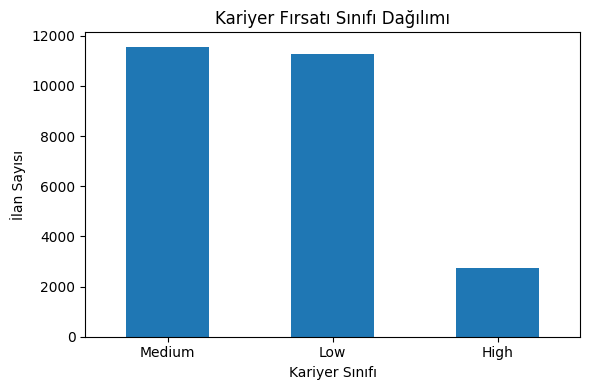

In [10]:
import matplotlib.pyplot as plt

class_counts = jobs_focus_final["career_class"].value_counts()

plt.figure(figsize=(6,4))
class_counts.plot(kind="bar")
plt.title("Kariyer Fırsatı Sınıfı Dağılımı")
plt.xlabel("Kariyer Sınıfı")
plt.ylabel("İlan Sayısı")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

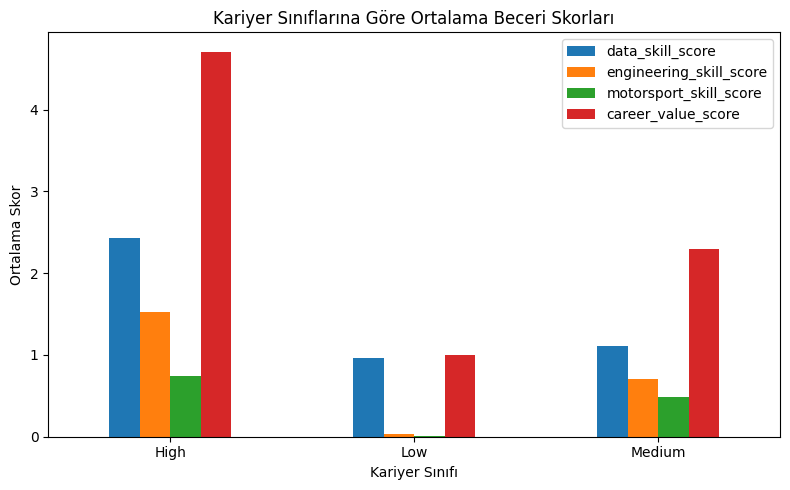

In [11]:
score_summary.plot(kind="bar", figsize=(8,5))
plt.title("Kariyer Sınıflarına Göre Ortalama Beceri Skorları")
plt.xlabel("Kariyer Sınıfı")
plt.ylabel("Ortalama Skor")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model_data = jobs_focus_final[
    [
        "data_skill_score",
        "engineering_skill_score",
        "motorsport_skill_score",
        "career_value_score",
        "career_class"
    ]
].dropna()

X = model_data[
    [
        "data_skill_score",
        "engineering_skill_score",
        "motorsport_skill_score",
        "career_value_score"
    ]
]

y = model_data["career_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
[[ 545    0    0]
 [   0 2258    0]
 [   0    0 2311]]

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       545
         Low       1.00      1.00      1.00      2258
      Medium       1.00      1.00      1.00      2311

    accuracy                           1.00      5114
   macro avg       1.00      1.00      1.00      5114
weighted avg       1.00      1.00      1.00      5114



In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model_data = jobs_focus_final[
    [
        "data_skill_score",
        "engineering_skill_score",
        "motorsport_skill_score",
        "career_class"
    ]
].dropna()

X = model_data[
    [
        "data_skill_score",
        "engineering_skill_score",
        "motorsport_skill_score"
    ]
]

y = model_data["career_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
[[ 545    0    0]
 [   0 2258    0]
 [   0    0 2311]]

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       545
         Low       1.00      1.00      1.00      2258
      Medium       1.00      1.00      1.00      2311

    accuracy                           1.00      5114
   macro avg       1.00      1.00      1.00      5114
weighted avg       1.00      1.00      1.00      5114



In [14]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model_df = jobs_focus_final[
    [
        "job_title",
        "search_country",
        "job_level",
        "job_type",
        "career_class"
    ]
].dropna().copy()

X = model_df[
    [
        "job_title",
        "search_country",
        "job_level",
        "job_type"
    ]
]

y = model_df["career_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

preprocess = ColumnTransformer(
    transformers=[
        ("title_tfidf", TfidfVectorizer(max_features=1000, stop_words="english"), "job_title"),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["search_country", "job_level", "job_type"])
    ]
)

model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6163472819710598

Confusion Matrix:
[[ 246   91  208]
 [  82 1532  644]
 [ 210  727 1374]]

Classification Report:
              precision    recall  f1-score   support

        High       0.46      0.45      0.45       545
         Low       0.65      0.68      0.66      2258
      Medium       0.62      0.59      0.61      2311

    accuracy                           0.62      5114
   macro avg       0.58      0.57      0.57      5114
weighted avg       0.62      0.62      0.62      5114



In [15]:
import numpy as np
import pandas as pd

# Pipeline içinden feature isimlerini alma
preprocessor = model.named_steps["preprocess"]
classifier = model.named_steps["classifier"]

title_features = preprocessor.named_transformers_["title_tfidf"].get_feature_names_out()
cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(
    ["search_country", "job_level", "job_type"]
)

feature_names = np.concatenate([title_features, cat_features])
importances = classifier.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(30)

,feature,importance
319,engineer,0.047377
240,data,0.039502
815,senior,0.032594
840,software,0.020558
53,analyst,0.017731
855,sr,0.016662
263,developer,0.015808
1003,search_country_United States,0.012809
546,manager,0.012527
893,systems,0.012447


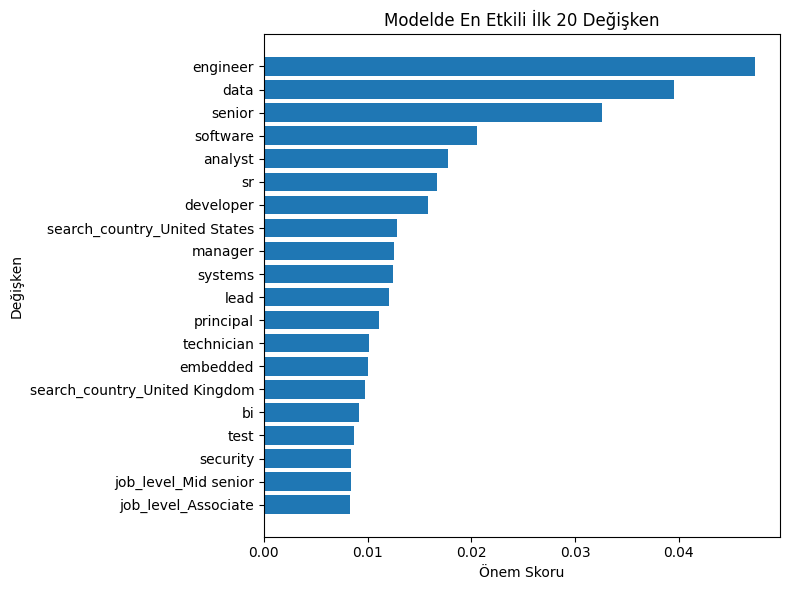

In [16]:
top_importance = importance_df.head(20).sort_values("importance")

plt.figure(figsize=(8,6))
plt.barh(top_importance["feature"], top_importance["importance"])
plt.title("Modelde En Etkili İlk 20 Değişken")
plt.xlabel("Önem Skoru")
plt.ylabel("Değişken")
plt.tight_layout()
plt.show()


In [17]:
def candidate_match_score(skill_text, candidate_skills):
    skill_text = str(skill_text).lower()
    return sum(skill.lower() in skill_text for skill in candidate_skills)

basic_candidate_skills = [
    "python",
    "sql"
]

advanced_candidate_skills = [
    "python",
    "sql",
    "matlab",
    "simulation",
    "telemetry",
    "embedded",
    "data analysis"
]

jobs_focus_final["basic_candidate_match"] = jobs_focus_final["job_skills"].apply(
    lambda x: candidate_match_score(x, basic_candidate_skills)
)

jobs_focus_final["advanced_candidate_match"] = jobs_focus_final["job_skills"].apply(
    lambda x: candidate_match_score(x, advanced_candidate_skills)
)

basic_accessible_jobs = jobs_focus_final[jobs_focus_final["basic_candidate_match"] >= 1]
advanced_accessible_jobs = jobs_focus_final[jobs_focus_final["advanced_candidate_match"] >= 2]

print("Temel aday erişilebilir ilan sayısı:", len(basic_accessible_jobs))
print("Gelişmiş aday erişilebilir ilan sayısı:", len(advanced_accessible_jobs))

increase = len(advanced_accessible_jobs) - len(basic_accessible_jobs)
increase_rate = increase / len(basic_accessible_jobs) * 100

print("İlan sayısı artışı:", increase)
print("Yüzdesel artış:", round(increase_rate, 2), "%")

Temel aday erişilebilir ilan sayısı: 13098
Gelişmiş aday erişilebilir ilan sayısı: 6538
İlan sayısı artışı: -6560
Yüzdesel artış: -50.08 %


In [18]:
simulation_summary = pd.DataFrame({
    "Senaryo": ["Temel Aday", "Gelişmiş Aday"],
    "Erişilebilir İlan Sayısı": [
        len(basic_accessible_jobs),
        len(advanced_accessible_jobs)
    ],
    "High İlan Sayısı": [
        (basic_accessible_jobs["career_class"] == "High").sum(),
        (advanced_accessible_jobs["career_class"] == "High").sum()
    ],
    "Medium + High İlan Sayısı": [
        basic_accessible_jobs["career_class"].isin(["Medium", "High"]).sum(),
        advanced_accessible_jobs["career_class"].isin(["Medium", "High"]).sum()
    ],
    "Ortalama Kariyer Değer Skoru": [
        basic_accessible_jobs["career_value_score"].mean(),
        advanced_accessible_jobs["career_value_score"].mean()
    ]
})

simulation_summary["High İlan Oranı (%)"] = (
    simulation_summary["High İlan Sayısı"] /
    simulation_summary["Erişilebilir İlan Sayısı"] * 100
).round(2)

simulation_summary["Medium + High Oranı (%)"] = (
    simulation_summary["Medium + High İlan Sayısı"] /
    simulation_summary["Erişilebilir İlan Sayısı"] * 100
).round(2)

simulation_summary

,Senaryo,Erişilebilir İlan Sayısı,High İlan Sayısı,Medium + High İlan Sayısı,Ortalama Kariyer Değer Skoru,High İlan Oranı (%),Medium + High Oranı (%)
0,Temel Aday,13098,1813,7003,2.057108,13.84,53.47
1,Gelişmiş Aday,6538,2060,6538,3.188437,31.51,100.00


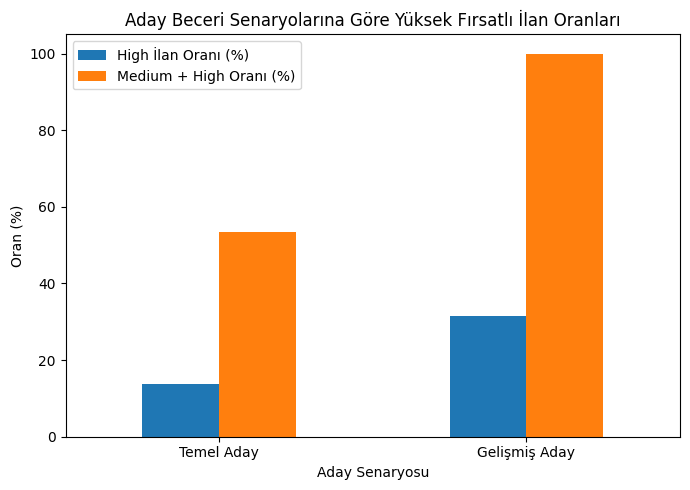

In [19]:
simulation_summary_plot = simulation_summary.set_index("Senaryo")[
    [
        "High İlan Oranı (%)",
        "Medium + High Oranı (%)"
    ]
]

simulation_summary_plot.plot(kind="bar", figsize=(7,5))
plt.title("Aday Beceri Senaryolarına Göre Yüksek Fırsatlı İlan Oranları")
plt.xlabel("Aday Senaryosu")
plt.ylabel("Oran (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
external_skill_reference = pd.DataFrame({
    "skill": [
        "python",
        "sql",
        "data analysis",
        "machine learning",
        "matlab",
        "simulink",
        "simulation",
        "cfd",
        "telemetry",
        "vehicle dynamics",
        "aerodynamics",
        "powertrain",
        "calibration",
        "embedded",
        "data acquisition"
    ],
    "external_relevance_weight": [
        2, 1, 2, 2,
        3, 3, 3, 3,
        3, 3, 3, 3,
        3, 2, 3
    ],
    "skill_group": [
        "Data", "Data", "Data", "Data",
        "Engineering", "Engineering", "Engineering", "Engineering",
        "Motorsport/Performance", "Motorsport/Performance",
        "Motorsport/Performance", "Motorsport/Performance",
        "Motorsport/Performance", "Engineering", "Motorsport/Performance"
    ]
})

external_skill_reference

,skill,external_relevance_weight,skill_group
0,python,2,Data
1,sql,1,Data
2,data analysis,2,Data
3,machine learning,2,Data
4,matlab,3,Engineering
5,simulink,3,Engineering
6,simulation,3,Engineering
7,cfd,3,Engineering
8,telemetry,3,Motorsport/Performance
9,vehicle dynamics,3,Motorsport/Performance


In [21]:
def calculate_external_weighted_score(skill_text, reference_df):
    skill_text = str(skill_text).lower()
    score = 0
    
    for _, row in reference_df.iterrows():
        skill = row["skill"].lower()
        weight = row["external_relevance_weight"]
        
        if skill in skill_text:
            score += weight
            
    return score

jobs_focus_final["external_weighted_skill_score"] = jobs_focus_final["job_skills"].apply(
    lambda x: calculate_external_weighted_score(x, external_skill_reference)
)

print("Ortalama dış kaynak ağırlıklı beceri skoru:")
print(jobs_focus_final["external_weighted_skill_score"].mean())

print("\nKariyer sınıfına göre dış kaynak ağırlıklı beceri skoru:")
print(
    jobs_focus_final.groupby("career_class")["external_weighted_skill_score"]
    .mean()
    .round(2)
)

Ortalama dış kaynak ağırlıklı beceri skoru:
2.907000391083301

Kariyer sınıfına göre dış kaynak ağırlıklı beceri skoru:
career_class
High      6.21
Low       1.72
Medium    3.29
Name: external_weighted_skill_score, dtype: float64


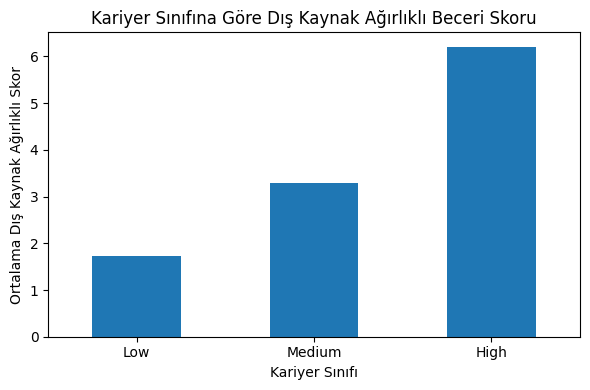

In [22]:
external_score_summary = jobs_focus_final.groupby("career_class")[
    "external_weighted_skill_score"
].mean().reindex(["Low", "Medium", "High"])

plt.figure(figsize=(6,4))
external_score_summary.plot(kind="bar")
plt.title("Kariyer Sınıfına Göre Dış Kaynak Ağırlıklı Beceri Skoru")
plt.xlabel("Kariyer Sınıfı")
plt.ylabel("Ortalama Dış Kaynak Ağırlıklı Skor")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
jobs_focus_final.to_csv(
    "data/motorsport_performance_focus_final_enriched.csv",
    index=False
)

# Özet tabloları kaydetme
score_summary.to_csv("data/score_summary_by_career_class.csv")
simulation_summary.to_csv("data/candidate_skill_simulation_summary.csv", index=False)
importance_df.head(50).to_csv("data/model_feature_importance_top50.csv", index=False)
external_score_summary.to_csv("data/external_weighted_score_summary.csv")

print("Kaydedilen dosyalar:")
print("1. data/motorsport_performance_focus_final_enriched.csv")
print("2. data/score_summary_by_career_class.csv")
print("3. data/candidate_skill_simulation_summary.csv")
print("4. data/model_feature_importance_top50.csv")
print("5. data/external_weighted_score_summary.csv")

Kaydedilen dosyalar:
1. data/motorsport_performance_focus_final_enriched.csv
2. data/score_summary_by_career_class.csv
3. data/candidate_skill_simulation_summary.csv
4. data/model_feature_importance_top50.csv
5. data/external_weighted_score_summary.csv


In [24]:
print("Nihai veri seti boyutu:")
print(jobs_focus_final.shape)

print("\nEksik değer sayıları:")
print(jobs_focus_final[
    [
        "job_title",
        "company",
        "search_country",
        "job_level",
        "job_type",
        "job_skills",
        "career_class",
        "data_skill_score",
        "engineering_skill_score",
        "motorsport_skill_score",
        "career_value_score",
        "external_weighted_skill_score"
    ]
].isnull().sum())

print("\nKariyer sınıfı dağılımı:")
print(jobs_focus_final["career_class"].value_counts())

print("\nCareer value score özet:")
print(jobs_focus_final["career_value_score"].describe())

print("\nExternal weighted skill score özet:")
print(jobs_focus_final["external_weighted_skill_score"].describe())

print("\nCareer class ve score uyumu:")
print(
    jobs_focus_final.groupby("career_class")[
        [
            "data_skill_score",
            "engineering_skill_score",
            "motorsport_skill_score",
            "career_value_score",
            "external_weighted_skill_score"
        ]
    ].mean().round(2)
)

Nihai veri seti boyutu:
(25570, 26)

Eksik değer sayıları:
job_title                        0
company                          0
search_country                   0
job_level                        0
job_type                         0
job_skills                       0
career_class                     0
data_skill_score                 0
engineering_skill_score          0
motorsport_skill_score           0
career_value_score               0
external_weighted_skill_score    0
dtype: int64

Kariyer sınıfı dağılımı:
career_class
Medium    11556
Low       11290
High       2724
Name: count, dtype: int64

Career value score özet:
count    25570.000000
mean         1.978686
std          1.207635
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max         12.000000
Name: career_value_score, dtype: float64

External weighted skill score özet:
count    25570.000000
mean         2.907000
std          1.928691
min          1.000000
25%          2.000000
50%  

In [25]:
external_skill_reference["source_note"] = "Motorsport and performance automotive technical skill reference"
external_skill_reference["source_type"] = "External domain reference"

external_skill_reference.to_csv(
    "data/external_skill_reference.csv",
    index=False
)

print("Dış beceri referans tablosu kaydedildi:")
print("data/external_skill_reference.csv")

external_skill_reference

Dış beceri referans tablosu kaydedildi:
data/external_skill_reference.csv


,skill,external_relevance_weight,skill_group,source_note,source_type
0,python,2,Data,Motorsport and performance automotive technica...,External domain reference
1,sql,1,Data,Motorsport and performance automotive technica...,External domain reference
2,data analysis,2,Data,Motorsport and performance automotive technica...,External domain reference
3,machine learning,2,Data,Motorsport and performance automotive technica...,External domain reference
4,matlab,3,Engineering,Motorsport and performance automotive technica...,External domain reference
5,simulink,3,Engineering,Motorsport and performance automotive technica...,External domain reference
6,simulation,3,Engineering,Motorsport and performance automotive technica...,External domain reference
7,cfd,3,Engineering,Motorsport and performance automotive technica...,External domain reference
8,telemetry,3,Motorsport/Performance,Motorsport and performance automotive technica...,External domain reference
9,vehicle dynamics,3,Motorsport/Performance,Motorsport and performance automotive technica...,External domain reference


In [4]:
import pandas as pd

jobs_focus_final = pd.read_csv(
    "data/motorsport_performance_focus_final_enriched.csv",
    low_memory=False
)

print(jobs_focus_final.shape)
print(jobs_focus_final.columns)

(25570, 26)
Index(['job_link', 'last_processed_time', 'got_summary', 'got_ner',
       'is_being_worked', 'job_title', 'company', 'job_location', 'first_seen',
       'search_city', 'search_country', 'search_position', 'job_level',
       'job_type', 'job_skills', 'skill_text', 'title_text', 'company_text',
       'data_skill_score', 'engineering_skill_score', 'motorsport_skill_score',
       'career_value_score', 'career_class', 'basic_candidate_match',
       'advanced_candidate_match', 'external_weighted_skill_score'],
      dtype='str')


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Final ana model: Linear SVC
final_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("classifier", LinearSVC(
            class_weight="balanced",
            random_state=42
        ))
    ]
)

final_model.fit(X_train, y_train)

y_pred_final = final_model.predict(X_test)

print("Final Model: Linear SVC")
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

# Feature isimlerini alma
preprocessor = final_model.named_steps["preprocess"]
classifier = final_model.named_steps["classifier"]

text_features = preprocessor.named_transformers_["text_tfidf"].get_feature_names_out()
cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(
    ["search_country", "job_level", "job_type"]
)

feature_names = np.concatenate([text_features, cat_features])

# LinearSVC çok sınıflı modelde her sınıf için katsayı üretir.
# Genel önem için mutlak katsayıların ortalamasını alıyoruz.
importance_values = np.abs(classifier.coef_).mean(axis=0)

svc_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance_values
}).sort_values("importance", ascending=False)

svc_importance_df.head(30)

Final Model: Linear SVC
Accuracy: 0.8247946812671099

Confusion Matrix:
[[ 402    0  143]
 [   0 2099  159]
 [ 204  390 1717]]

Classification Report:
              precision    recall  f1-score   support

        High       0.66      0.74      0.70       545
         Low       0.84      0.93      0.88      2258
      Medium       0.85      0.74      0.79      2311

    accuracy                           0.82      5114
   macro avg       0.79      0.80      0.79      5114
weighted avg       0.83      0.82      0.82      5114



,feature,importance
4023,simulation,9.629642
605,calibration,9.531427
4032,simulations,6.502555
259,analytics,5.910796
4299,statistics,5.721125
983,control systems,5.540406
3503,python,5.348793
1078,data acquisition,5.125277
672,cfd,4.874319
4472,tableau,4.836825


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Final ana model: Linear SVC
final_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("classifier", LinearSVC(
            class_weight="balanced",
            random_state=42
        ))
    ]
)

final_model.fit(X_train, y_train)

y_pred_final = final_model.predict(X_test)

print("Final Model: Linear SVC")
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

# Feature isimlerini alma
preprocessor = final_model.named_steps["preprocess"]
classifier = final_model.named_steps["classifier"]

text_features = preprocessor.named_transformers_["text_tfidf"].get_feature_names_out()
cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(
    ["search_country", "job_level", "job_type"]
)

feature_names = np.concatenate([text_features, cat_features])

# LinearSVC çok sınıflı modelde her sınıf için katsayı üretir.
# Genel önem için mutlak katsayıların ortalamasını alıyoruz.
importance_values = np.abs(classifier.coef_).mean(axis=0)

svc_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance_values
}).sort_values("importance", ascending=False)

svc_importance_df.head(30)

Final Model: Linear SVC
Accuracy: 0.8247946812671099

Confusion Matrix:
[[ 402    0  143]
 [   0 2099  159]
 [ 204  390 1717]]

Classification Report:
              precision    recall  f1-score   support

        High       0.66      0.74      0.70       545
         Low       0.84      0.93      0.88      2258
      Medium       0.85      0.74      0.79      2311

    accuracy                           0.82      5114
   macro avg       0.79      0.80      0.79      5114
weighted avg       0.83      0.82      0.82      5114



,feature,importance
4023,simulation,9.629642
605,calibration,9.531427
4032,simulations,6.502555
259,analytics,5.910796
4299,statistics,5.721125
983,control systems,5.540406
3503,python,5.348793
1078,data acquisition,5.125277
672,cfd,4.874319
4472,tableau,4.836825


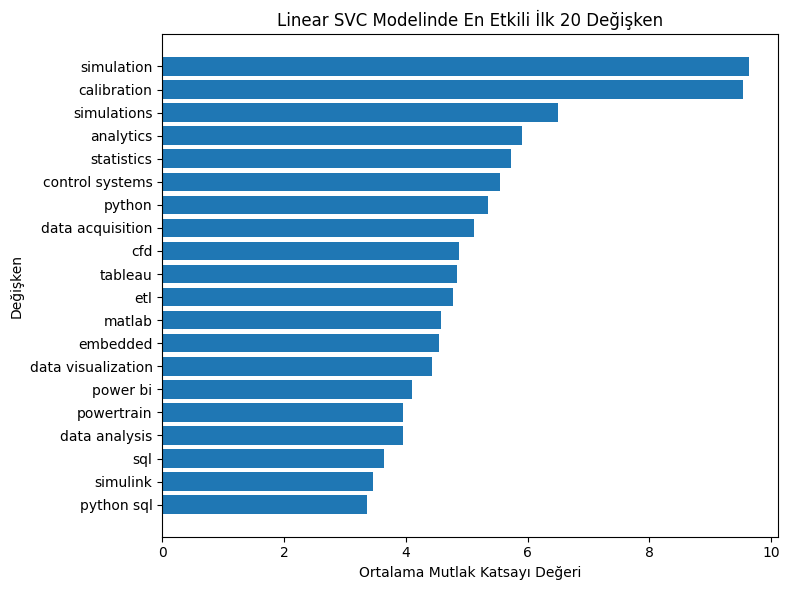

In [7]:
top_svc_importance = svc_importance_df.head(20).sort_values("importance")

plt.figure(figsize=(8,6))
plt.barh(top_svc_importance["feature"], top_svc_importance["importance"])
plt.title("Linear SVC Modelinde En Etkili İlk 20 Değişken")
plt.xlabel("Ortalama Mutlak Katsayı Değeri")
plt.ylabel("Değişken")
plt.tight_layout()
plt.show()

In [8]:
svc_importance_df.head(50).to_csv(
    "data/linear_svc_feature_importance_top50.csv",
    index=False
)

final_model_results = pd.DataFrame({
    "model": ["Linear SVC"],
    "accuracy": [0.8247946812671099],
    "macro_f1": [0.79],
    "weighted_f1": [0.82]
})

final_model_results.to_csv(
    "data/final_model_results.csv",
    index=False
)

print("Kaydedildi:")
print("data/linear_svc_feature_importance_top50.csv")
print("data/final_model_results.csv")

Kaydedildi:
data/linear_svc_feature_importance_top50.csv
data/final_model_results.csv


In [9]:
svc_importance_df.head(50).to_csv(
    "data/linear_svc_feature_importance_top50.csv",
    index=False
)

final_model_results = pd.DataFrame({
    "model": ["Linear SVC"],
    "accuracy": [0.8247946812671099],
    "macro_f1": [0.79],
    "weighted_f1": [0.82]
})

final_model_results.to_csv(
    "data/final_model_results.csv",
    index=False
)

print("Kaydedildi:")
print("data/linear_svc_feature_importance_top50.csv")
print("data/final_model_results.csv")

Kaydedildi:
data/linear_svc_feature_importance_top50.csv
data/final_model_results.csv


In [1]:
print("=== FINAL RAPOR KONTROL ===")

print("Final veri seti boyutu:", jobs_focus_final.shape)

print("\nKariyer sınıfı dağılımı:")
print(jobs_focus_final["career_class"].value_counts())

print("\nCareer value score ortalamaları:")
print(
    jobs_focus_final.groupby("career_class")["career_value_score"]
    .mean()
    .round(2)
    .reindex(["Low", "Medium", "High"])
)

print("\nExternal weighted skill score ortalamaları:")
print(
    jobs_focus_final.groupby("career_class")["external_weighted_skill_score"]
    .mean()
    .round(2)
    .reindex(["Low", "Medium", "High"])
)

print("\nExternal skill reference beceri sayısı:")
print(len(external_skill_reference))

print("\nFinal model sonucu:")
print(final_model_results)

=== FINAL RAPOR KONTROL ===


NameError: name 'jobs_focus_final' is not defined

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print("=== FINAL RAPOR KONTROL ===")

print("Final veri seti boyutu:", jobs_focus_final.shape)

print("\nKariyer sınıfı dağılımı:")
print(jobs_focus_final["career_class"].value_counts())

print("\nCareer value score ortalamaları:")
print(
    jobs_focus_final.groupby("career_class")["career_value_score"]
    .mean()
    .round(2)
    .reindex(["Low", "Medium", "High"])
)

print("\nExternal weighted skill score ortalamaları:")
print(
    jobs_focus_final.groupby("career_class")["external_weighted_skill_score"]
    .mean()
    .round(2)
    .reindex(["Low", "Medium", "High"])
)

print("\nExternal skill reference beceri sayısı:")
print(len(external_skill_reference))

print("\nFinal model sonucu:")
print(final_model_results)

=== FINAL RAPOR KONTROL ===


NameError: name 'jobs_focus_final' is not defined

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Kernel sıfırlandıysa kayıtlı dosyalardan tekrar yükle
jobs_focus_final = pd.read_csv(
    "data/motorsport_performance_focus_final_enriched.csv",
    low_memory=False
)

external_skill_reference = pd.read_csv(
    "data/external_skill_reference.csv"
)

final_model_results = pd.read_csv(
    "data/final_model_results.csv"
)

print("=== FINAL RAPOR KONTROL ===")

print("Final veri seti boyutu:", jobs_focus_final.shape)

print("\nKariyer sınıfı dağılımı:")
print(jobs_focus_final["career_class"].value_counts())

print("\nCareer value score ortalamaları:")
print(
    jobs_focus_final.groupby("career_class")["career_value_score"]
    .mean()
    .round(2)
    .reindex(["Low", "Medium", "High"])
)

print("\nExternal weighted skill score ortalamaları:")
print(
    jobs_focus_final.groupby("career_class")["external_weighted_skill_score"]
    .mean()
    .round(2)
    .reindex(["Low", "Medium", "High"])
)

print("\nExternal skill reference beceri sayısı:")
print(len(external_skill_reference))

print("\nFinal model sonucu:")
print(final_model_results)

=== FINAL RAPOR KONTROL ===
Final veri seti boyutu: (25570, 26)

Kariyer sınıfı dağılımı:
career_class
Medium    11556
Low       11290
High       2724
Name: count, dtype: int64

Career value score ortalamaları:
career_class
Low       1.00
Medium    2.29
High      4.71
Name: career_value_score, dtype: float64

External weighted skill score ortalamaları:
career_class
Low       1.72
Medium    3.29
High      6.21
Name: external_weighted_skill_score, dtype: float64

External skill reference beceri sayısı:
15

Final model sonucu:
        model  accuracy  macro_f1  weighted_f1
0  Linear SVC  0.824795      0.79         0.82


=== FINAL RAPOR KONTROL ===
Final veri seti boyutu: (25570, 26)

Kariyer sınıfı dağılımı:
career_class
Medium    11556
Low       11290
High       2724
Name: count, dtype: int64

Career value score ortalamaları:
career_class
Low       1.00
Medium    2.29
High      4.71
Name: career_value_score, dtype: float64

External weighted skill score ortalamaları:
career_class
Low       1.72
Medium    3.29
High      6.21
Name: external_weighted_skill_score, dtype: float64

External skill reference beceri sayısı:
15

Final model sonucu:
        model  accuracy  macro_f1  weighted_f1
0  Linear SVC  0.824795      0.79         0.82

Bu bölüm, raporda kullanılan tüm temel sayıların notebook çıktıları ile tutarlı olduğunu doğrulamak amacıyla eklenmiştir.

Kontrol edilenler:

- Final veri seti boyutu
- Kariyer sınıfı dağılımı
- Career Value Score ortalamaları
- External Weighted Skill Score ortalamaları
- External Skill Reference tablosu
- Final model performansı